In [1]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor

In [2]:
df = pd.read_excel("properties.xlsx")

In [3]:
df.head()

,Name,Price,Sqft,BHK,Location,Locality,Price Per Sqft,Years,rental_yield,risk_score
0,Sheth Montana,28000000.0,977,3 BHK,Mulund West,Mumbai,28659.160696,3,4.853634,2.646366
1,Wadhwa Imperial Heights,57500000.0,1450,3.5 BHK,Goregaon West,Mumbai,39655.172414,3,4.413793,3.086207
2,Bredco New Viceroy Park,65000000.0,1100,3 BHK,Bandra West,Mumbai,59090.909091,3,3.636364,3.863636
3,Dosti Eastern Bay Phase 2,35000000.0,950,2.5 BHK,Kandivali East,Mumbai,36842.105263,3,4.526316,2.973684
4,Saroj CHS,23500000.0,750,2 BHK,Wadala,Mumbai,31333.333333,3,4.746667,2.753333


In [4]:
df.describe()

,Price,Sqft,Price Per Sqft,Years,rental_yield,risk_score
count,1.685900e+04,16859.000000,16859.000000,16859.000000,16859.000000,16859.000000
mean,2.870545e+07,891.627617,31894.167761,5.576725,4.725651,4.062978
std,2.012237e+07,676.990981,12525.290788,2.772930,0.492574,1.478435
min,4.000000e+06,140.000000,1092.307692,1.000000,2.500000,1.000000
25%,1.420000e+07,565.000000,24257.667359,4.000000,4.546667,2.933535
50%,2.250000e+07,769.000000,29268.292683,5.000000,4.829268,3.851690
75%,3.600000e+07,1088.000000,36333.333333,8.000000,5.029693,5.225115
max,1.000000e+08,32500.000000,183800.000000,10.000000,5.956308,8.500000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16859 entries, 0 to 16858
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Name            16859 non-null  object 
 1   Price           16859 non-null  float64
 2   Sqft            16859 non-null  int64  
 3   BHK             16859 non-null  object 
 4   Location        16859 non-null  object 
 5   Locality        16849 non-null  object 
 6   Price Per Sqft  16859 non-null  float64
 7   Years           16859 non-null  int64  
 8   rental_yield    16859 non-null  float64
 9   risk_score      16859 non-null  float64
dtypes: float64(4), int64(2), object(4)
memory usage: 1.3+ MB


In [6]:
le = LabelEncoder()
df["locality_encoded"] = le.fit_transform(df['Location'])

In [7]:
df.head()

,Name,Price,Sqft,BHK,Location,Locality,Price Per Sqft,Years,rental_yield,risk_score,locality_encoded
0,Sheth Montana,28000000.0,977,3 BHK,Mulund West,Mumbai,28659.160696,3,4.853634,2.646366,266
1,Wadhwa Imperial Heights,57500000.0,1450,3.5 BHK,Goregaon West,Mumbai,39655.172414,3,4.413793,3.086207,138
2,Bredco New Viceroy Park,65000000.0,1100,3 BHK,Bandra West,Mumbai,59090.909091,3,3.636364,3.863636,31
3,Dosti Eastern Bay Phase 2,35000000.0,950,2.5 BHK,Kandivali East,Mumbai,36842.105263,3,4.526316,2.973684,181
4,Saroj CHS,23500000.0,750,2 BHK,Wadala,Mumbai,31333.333333,3,4.746667,2.753333,404


In [8]:
df['locality_encoded'].value_counts()

locality_encoded
236    1748
235    1162
181    1019
137     908
13      858
       ... 
140       1
376       1
69        1
295       1
151       1
Name: count, Length: 421, dtype: int64

In [9]:
df['BHK'] = df['BHK'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

In [10]:
# Feature & Target Splits
X = df[["locality_encoded", "Sqft", "BHK", "Price Per Sqft", "Years", "rental_yield"]]
y_price = df["Price"]  # Predicting price
y_risk = df["risk_score"]  # Predicting risk

In [11]:
X_train, X_test, y_price_train, y_price_test = train_test_split(X, y_price, test_size=0.2, random_state=42)
X_train2, X_test2, y_risk_train, y_risk_test = train_test_split(X, y_risk, test_size=0.2, random_state=42)

In [12]:
price_model = XGBRegressor(n_estimators=300, learning_rate=0.08)
risk_model = XGBRegressor(n_estimators=200, learning_rate=0.1)

In [13]:
price_model.fit(X_train, y_price_train)
risk_model.fit(X_train, y_risk_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [14]:
df.head()

,Name,Price,Sqft,BHK,Location,Locality,Price Per Sqft,Years,rental_yield,risk_score,locality_encoded
0,Sheth Montana,28000000.0,977,3.0,Mulund West,Mumbai,28659.160696,3,4.853634,2.646366,266
1,Wadhwa Imperial Heights,57500000.0,1450,3.5,Goregaon West,Mumbai,39655.172414,3,4.413793,3.086207,138
2,Bredco New Viceroy Park,65000000.0,1100,3.0,Bandra West,Mumbai,59090.909091,3,3.636364,3.863636,31
3,Dosti Eastern Bay Phase 2,35000000.0,950,2.5,Kandivali East,Mumbai,36842.105263,3,4.526316,2.973684,181
4,Saroj CHS,23500000.0,750,2.0,Wadala,Mumbai,31333.333333,3,4.746667,2.753333,404


In [15]:
price_pred = price_model.predict(X_test)
risk_pred = risk_model.predict(X_test2)

In [16]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

In [17]:
def evaluate_model(y_true, y_pred, name):
    print(f"\n📊 Evaluation for {name} Model:")
    print(f"R² Score: {r2_score(y_true, y_pred):.4f}")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")

In [18]:
evaluate_model(y_price_test, price_pred, "Price")
evaluate_model(y_risk_test, risk_pred, "Risk Score")


📊 Evaluation for Price Model:
R² Score: 0.9983
MAE: 303334.10
RMSE: 826507.00

📊 Evaluation for Risk Score Model:
R² Score: 0.9999
MAE: 0.01
RMSE: 0.01


In [19]:
scores = cross_val_score(price_model, X, y_price, cv=5, scoring='r2')
print("\n📌 Cross-Val R²:", np.round(scores, 3))
print("Average:", np.mean(scores).round(3))


📌 Cross-Val R²: [0.986 0.998 0.998 0.995 0.991]
Average: 0.994


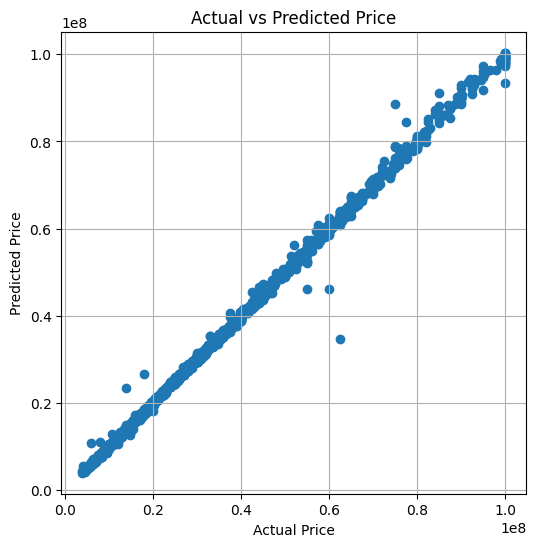

In [20]:
# Plot predicted vs actual for price
plt.figure(figsize=(6,6))
plt.scatter(y_price_test, price_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.grid(True)
plt.show()

In [22]:
from joblib import dump

dump(le, 'label_encoder.joblib')
dump(price_model, 'price_model.joblib')
dump(risk_model, 'risk_model.joblib')

print("✅ Models saved successfully!")

✅ Models saved successfully!
